# Analisis Listing Produk Tokopedia

Notebook ini menjawab empat pertanyaan bisnis memakai data bersih dari `02_data_prep_produk.ipynb`:

1. Bagaimana sebaran harga di setiap kategori produk?
2. Kota dan provinsi mana yang punya penjual paling aktif dan volume penjualan tertinggi?
3. Bagaimana hubungan rating, diskon, dan jumlah terjual? Apakah diskon yang lebih besar selalu membuat produk lebih laris?
4. Kata kunci apa yang sering dipakai di nama produk, dan bagaimana pengaruhnya terhadap harga?

Beberapa hal yang perlu diingat saat membaca hasilnya:

- Kolom `terjual` berasal dari teks seperti "100+ terjual", jadi nilainya adalah batas bawah dan mengelompok di angka bulat (100, 250, 500, 1.000, dan seterusnya). Karena itu median terjual sering jatuh tepat di angka-angka tersebut.
- Harga dan jumlah terjual sangat miring, jadi ukuran yang dipakai adalah median, bukan rata-rata.
- Data ini adalah potret listing pada satu waktu. Hasilnya menunjukkan hubungan, bukan sebab-akibat.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv("../Dataset/processed/produk_bersih.csv")
print(df.shape)
df.head()

(29068, 12)


,nama_produk,kategori,nama_toko,lokasi_toko,kota,provinsi,harga,diskon,terjual,jumlah_ulasan,rating,url
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Hewan Peliharaan,Lazy Dog Supply,Jakarta Selatan,Jakarta,DKI Jakarta,35000,0.0,1000.0,10.0,5.0,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,Hewan Peliharaan,RumahBully,Jakarta Timur,Jakarta,DKI Jakarta,79999,0.0,250.0,NaN,5.0,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,Hewan Peliharaan,RumahBully,Jakarta Barat,Jakarta,DKI Jakarta,33000,0.0,26.0,NaN,5.0,https://www.tokopedia.com/rumahbully/chicken-m...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG F...,Hewan Peliharaan,RumahBully,Tangerang Selatan,Tangerang Selatan,Banten,29900,0.0,100.0,NaN,5.0,https://www.tokopedia.com/rumahbully/promo-bul...
4,Premium Dog Food / Daging Sapi Giling / Raw Fo...,Hewan Peliharaan,RumahBully,Jakarta Selatan,Jakarta,DKI Jakarta,39000,0.0,1000.0,NaN,5.0,https://www.tokopedia.com/rumahbully/premium-d...


In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})


def rupiah(x):
    return "Rp" + f"{x:,.0f}".replace(",", ".")


def angka(x):
    return f"{x:,.0f}".replace(",", ".")

## 1. Sebaran harga per kategori

Setiap kategori diringkas dengan tiga angka:

- Kuartil 1 (Q1): 25% produk harganya di bawah angka ini.
- Median: harga tengah.
- Kuartil 3 (Q3): 75% produk harganya di bawah angka ini.

Jarak Q1 ke Q3 menunjukkan rentang harga "normal" di sebuah kategori. Semakin lebar jaraknya, semakin beragam harga di kategori itu.

In [3]:
harga_kategori = (
    df.groupby("kategori")["harga"]
    .agg(
        jumlah_produk="size",
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
    )
    .sort_values("median", ascending=False)
)
harga_kategori.style.format({"q1": rupiah, "median": rupiah, "q3": rupiah})

,jumlah_produk,q1,median,q3
kategori,,,,
Elektronik,4395,Rp112.250,Rp319.000,Rp1.549.000
Perhiasan,1195,Rp45.000,Rp240.000,Rp2.229.500
Handphone,997,Rp76.300,Rp189.000,Rp539.000
Olahraga,884,Rp62.500,Rp169.900,Rp563.250
Otomotif,1036,Rp41.982,Rp120.000,Rp395.438
Fashion,5481,Rp50.000,Rp118.499,Rp249.900
"Ibu, Bayi & Mainan",782,Rp45.000,Rp104.250,Rp248.000
Lainnya,3126,Rp28.925,Rp85.000,Rp347.750
Rumah Tangga,3967,Rp29.900,Rp81.000,Rp289.000


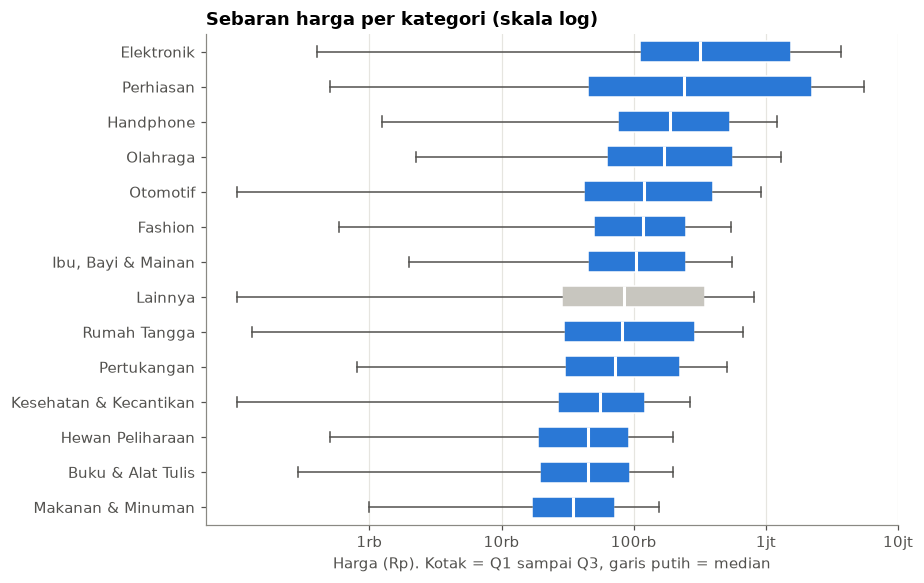

In [4]:
urutan = harga_kategori.sort_values("median").index
data_box = [df.loc[df["kategori"] == k, "harga"] for k in urutan]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
box = ax.boxplot(
    data_box,
    orientation="horizontal",
    tick_labels=urutan,
    showfliers=False,
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color=TEKS, linewidth=1),
    capprops=dict(color=TEKS, linewidth=1),
)
for patch, k in zip(box["boxes"], urutan):
    patch.set_facecolor(ABU if k == "Lainnya" else BIRU)
    patch.set_edgecolor("white")

ax.set_xscale("log")
ax.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
ax.set_xticklabels(["1rb", "10rb", "100rb", "1jt", "10jt"])
ax.minorticks_off()
ax.set_title("Sebaran harga per kategori (skala log)")
ax.set_xlabel("Harga (Rp). Kotak = Q1 sampai Q3, garis putih = median")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Temuan:

- Elektronik adalah kategori termahal dengan median sekitar Rp319.000. Kategori ini juga punya rentang harga yang sangat lebar, dari aksesoris murah seperti mouse sampai TV dan AC.
- Perhiasan punya rentang harga paling ekstrem. Mediannya Rp240.000, tetapi Q3-nya sekitar Rp2,2 juta, karena di kategori ini ada anting imitasi sekaligus emas batangan.
- Makanan & Minuman adalah kategori termurah dengan median sekitar Rp35.000 dan rentang harga yang sempit.
- Fashion, kategori dengan produk terbanyak, berada di tengah dengan median sekitar Rp118.500.

Implikasinya, membandingkan harga antarproduk hanya adil kalau dilakukan di dalam kategori yang sama. Harga Rp300.000 tergolong murah untuk Elektronik, tetapi mahal untuk Makanan & Minuman.

## 2. Analisis wilayah

Tiga ukuran dipakai untuk setiap wilayah:

- Jumlah toko: banyaknya nama toko berbeda. Ini ukuran penjual aktif.
- Total terjual: jumlah kolom `terjual` dari semua produk di wilayah itu. Ini ukuran volume penjualan.
- Median terjual: jumlah terjual produk yang berada di tengah. Ini ukuran seberapa laris produk yang umum di wilayah itu.

Produk dengan provinsi kosong (sebagian besar berlokasi "Indonesia") tidak diikutkan.

In [5]:
data_wilayah = df.dropna(subset=["provinsi"])

provinsi = (
    data_wilayah.groupby("provinsi")
    .agg(
        jumlah_toko=("nama_toko", "nunique"),
        jumlah_produk=("nama_produk", "size"),
        total_terjual=("terjual", "sum"),
        median_terjual=("terjual", "median"),
    )
    .sort_values("jumlah_toko", ascending=False)
)
provinsi["porsi_toko"] = provinsi["jumlah_toko"] / provinsi["jumlah_toko"].sum()
provinsi["porsi_terjual"] = provinsi["total_terjual"] / provinsi["total_terjual"].sum()

provinsi.head(10).style.format({
    "total_terjual": angka,
    "median_terjual": angka,
    "porsi_toko": "{:.1%}",
    "porsi_terjual": "{:.1%}",
})

,jumlah_toko,jumlah_produk,total_terjual,median_terjual,porsi_toko,porsi_terjual
provinsi,,,,,,
DKI Jakarta,6541,12972,32.121.217,60,45.9%,51.0%
Jawa Barat,2954,4991,14.265.363,50,20.7%,22.7%
Banten,1747,2962,9.743.570,90,12.2%,15.5%
Jawa Timur,1373,2335,2.531.477,30,9.6%,4.0%
Jawa Tengah,795,1313,2.556.917,21,5.6%,4.1%
DI Yogyakarta,225,404,1.253.388,20,1.6%,2.0%
Sumatera Utara,166,283,160.906,11,1.2%,0.3%
Bali,139,223,154.075,10,1.0%,0.2%
Sulawesi Selatan,81,122,37.273,12,0.6%,0.1%


In [6]:
kota = (
    df.dropna(subset=["kota"])
    .groupby("kota")
    .agg(
        jumlah_toko=("nama_toko", "nunique"),
        total_terjual=("terjual", "sum"),
        median_terjual=("terjual", "median"),
    )
    .sort_values("jumlah_toko", ascending=False)
)
kota.head(10).style.format({"total_terjual": angka, "median_terjual": angka})

,jumlah_toko,total_terjual,median_terjual
kota,,,
Jakarta,6541,32.121.217,60
Tangerang,1386,8.434.352,100
Bandung,1243,9.870.562,70
Surabaya,863,1.524.697,30
Bekasi,649,2.253.791,50
Bogor,386,481.973,30
Tangerang Selatan,361,1.286.293,50
Depok,297,319.099,30
Semarang,180,433.978,20


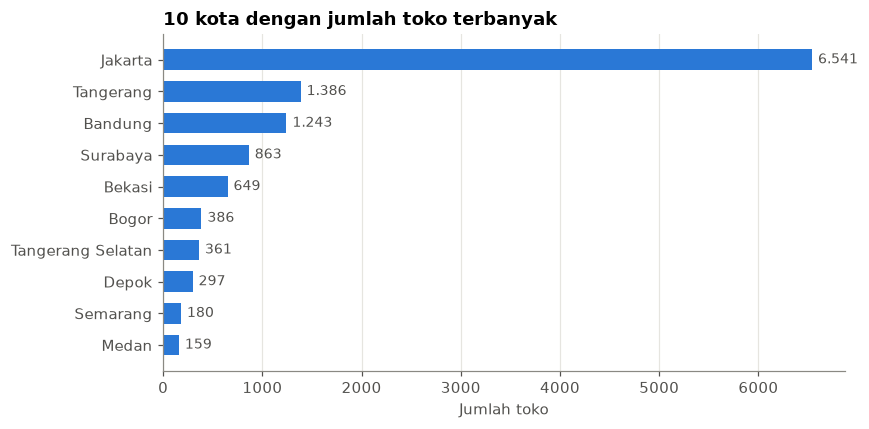

In [7]:
top_kota = kota.head(10).sort_values("jumlah_toko")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_kota.index, top_kota["jumlah_toko"], color=BIRU, height=0.65)
for y, v in enumerate(top_kota["jumlah_toko"]):
    ax.text(v + 60, y, angka(v), va="center", fontsize=9, color=TEKS)
ax.set_title("10 kota dengan jumlah toko terbanyak")
ax.set_xlabel("Jumlah toko")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [8]:
# Seberapa terpusat penjualan pada segelintir produk
urut = df["terjual"].dropna().sort_values(ascending=False)
print(f"30 produk terlaris menyumbang {urut.head(30).sum() / urut.sum():.0%} dari total terjual seluruh data")

30 produk terlaris menyumbang 29% dari total terjual seluruh data


Temuan:

- Penjual sangat terpusat di Pulau Jawa, terutama Jabodetabek. DKI Jakarta saja menyumbang 46% toko dan 51% total terjual. Jika digabung dengan Jawa Barat dan Banten, porsinya sekitar 90% dari total terjual.
- Di level kota, urutan teratas adalah Jakarta, Tangerang, Bandung, Surabaya, dan Bekasi.
- Median terjual tertinggi ada di Banten (90), lebih tinggi dari DKI Jakarta (60). Artinya, walaupun jumlah tokonya lebih sedikit, produk dari Banten (terutama Tangerang, dengan median 100) cenderung lebih laris. Ini mungkin berkaitan dengan banyaknya gudang dan toko besar di kawasan Tangerang, tetapi dugaan ini tidak bisa dibuktikan dari data ini.
- Di luar Jawa, jumlah toko dan penjualannya jauh lebih kecil. Sumatera Utara dan Bali masing-masing di bawah 1% dari total terjual.

Total terjual perlu dibaca dengan hati-hati. Angka ini sangat dipengaruhi segelintir produk yang sangat laris: 30 produk teratas saja menyumbang sekitar 29% dari seluruh penjualan. Karena itu, jumlah toko dan median terjual adalah ukuran yang lebih stabil untuk membandingkan wilayah.

## 3. Rating, diskon, dan jumlah terjual

Hubungan antarkolom diukur dengan korelasi Spearman. Nilainya berkisar dari -1 sampai 1:

- Mendekati 1: kalau satu naik, yang lain cenderung ikut naik.
- Mendekati -1: kalau satu naik, yang lain cenderung turun.
- Mendekati 0: tidak ada pola yang jelas.

Korelasi Spearman dipilih, bukan Pearson, karena Spearman membandingkan urutan (peringkat) nilai, bukan nilainya langsung. Cara ini lebih tahan terhadap data yang sangat miring dan outlier, seperti kolom harga dan terjual.

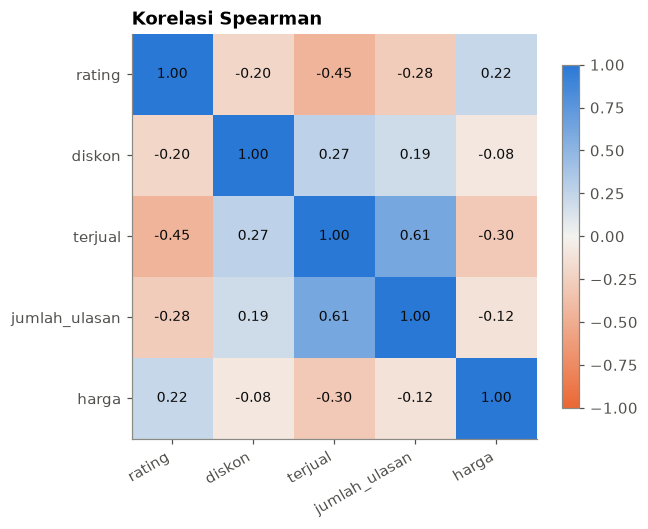

In [9]:
kolom = ["rating", "diskon", "terjual", "jumlah_ulasan", "harga"]
korelasi = df[kolom].corr(method="spearman")

peta_warna = LinearSegmentedColormap.from_list("oranye_biru", [ORANYE, "#f4f3ef", BIRU])

fig, ax = plt.subplots(figsize=(6, 5))
gambar = ax.imshow(korelasi, cmap=peta_warna, vmin=-1, vmax=1)
ax.set_xticks(range(len(kolom)))
ax.set_xticklabels(kolom, rotation=30, ha="right")
ax.set_yticks(range(len(kolom)))
ax.set_yticklabels(kolom)
for i in range(len(kolom)):
    for j in range(len(kolom)):
        ax.text(j, i, f"{korelasi.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9, color="#0b0b0b")
ax.grid(False)
ax.set_title("Korelasi Spearman")
fig.colorbar(gambar, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Diskon dan terjual berkorelasi positif, tetapi lemah (0,27). Rating dan terjual justru berkorelasi negatif (-0,45), yang terlihat aneh. Kedua hal ini dibahas lebih rinci di bawah.

### 3a. Apakah diskon yang lebih besar selalu membuat produk lebih laris?

Produk dikelompokkan berdasarkan besar diskonnya. Untuk setiap kelompok dihitung median terjual dan persentase produk laris. Di sini, produk laris didefinisikan sebagai produk yang terjual minimal 1.000.

In [10]:
df["kelompok_diskon"] = pd.cut(
    df["diskon"],
    bins=[-0.1, 0, 10, 25, 50, 100],
    labels=["0%", "1-10%", "11-25%", "26-50%", ">50%"],
)

per_diskon = df.groupby("kelompok_diskon", observed=True).agg(
    jumlah_produk=("terjual", "size"),
    median_terjual=("terjual", "median"),
    persen_laris=("terjual", lambda s: (s >= 1_000).mean()),
    median_harga=("harga", "median"),
)
per_diskon.style.format({"median_terjual": angka, "persen_laris": "{:.1%}", "median_harga": rupiah})

,jumlah_produk,median_terjual,persen_laris,median_harga
kelompok_diskon,,,,
0%,19010,26,11.6%,Rp110.000
1-10%,2431,100,22.7%,Rp99.000
11-25%,1996,100,26.4%,Rp94.050
26-50%,3236,100,28.7%,Rp88.000
>50%,2395,168,33.6%,Rp75.000


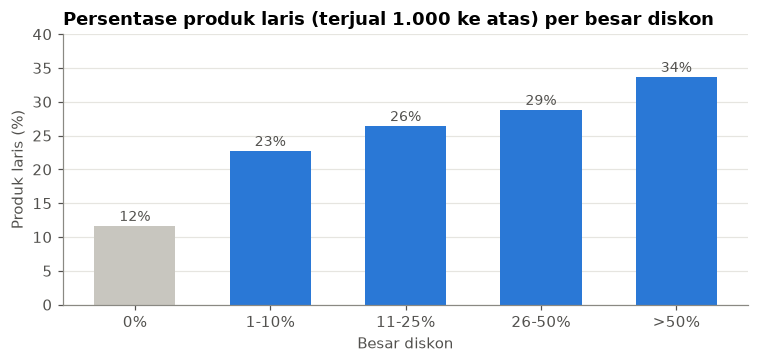

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.4))
warna = [ABU] + [BIRU] * (len(per_diskon) - 1)
ax.bar(per_diskon.index.astype(str), per_diskon["persen_laris"] * 100, color=warna, width=0.6)
for x, v in enumerate(per_diskon["persen_laris"] * 100):
    ax.text(x, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9, color=TEKS)
ax.set_ylim(0, 40)
ax.set_title("Persentase produk laris (terjual 1.000 ke atas) per besar diskon")
ax.set_xlabel("Besar diskon")
ax.set_ylabel("Produk laris (%)")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [12]:
# Apakah pola yang sama muncul di setiap kategori?
per_kategori = (
    df.assign(ada_diskon=np.where(df["diskon"] > 0, "dengan diskon", "tanpa diskon"))
    .groupby(["kategori", "ada_diskon"])["terjual"]
    .median()
    .unstack()
)
per_kategori["selisih_kali"] = per_kategori["dengan diskon"] / per_kategori["tanpa diskon"]
per_kategori.sort_values("selisih_kali")

ada_diskon,dengan diskon,tanpa diskon,selisih_kali
kategori,,,
Pertukangan,100.0,60.0,1.666667
Hewan Peliharaan,100.0,50.0,2.000000
Makanan & Minuman,250.0,100.0,2.500000
Rumah Tangga,100.0,29.0,3.448276
Olahraga,100.0,28.0,3.571429
Otomotif,70.0,15.0,4.666667
Lainnya,100.0,21.0,4.761905
Buku & Alat Tulis,100.0,20.0,5.000000
Fashion,100.0,20.0,5.000000


In [13]:
diskon_besar = df[df["diskon"] > 50]
print(f"Produk dengan diskon di atas 50%: {len(diskon_besar):,}")
print(f"Yang terjual kurang dari 10     : {(diskon_besar['terjual'] < 10).mean():.0%}")

Produk dengan diskon di atas 50%: 2,395
Yang terjual kurang dari 10     : 15%


Temuan:

- Produk berdiskon memang cenderung lebih laris. Median terjual produk tanpa diskon adalah 26, sedangkan produk berdiskon berapa pun besarnya sekitar 100. Pola ini muncul di semua kategori.
- Semakin besar diskon, semakin tinggi persentase produk laris, dari 12% (tanpa diskon) menjadi 34% (diskon di atas 50%). Namun, kenaikan terbesar terjadi saat produk mulai diberi diskon (dari 0% ke 1-10%). Setelah itu kenaikannya jauh lebih landai.
- Jawabannya: tidak, diskon besar tidak selalu membuat produk laris. Di kelompok diskon di atas 50%, dua pertiga produk tetap tidak mencapai 1.000 terjual, dan sekitar 15% bahkan terjual kurang dari 10.

Ada juga kemungkinan hubungan ini tidak sepenuhnya sebab-akibat. Toko yang sering memberi diskon bisa jadi memang toko besar atau official store yang sudah punya banyak pembeli. Selain itu, produk berdiskon di data ini harganya cenderung lebih murah (median Rp75.000 untuk diskon di atas 50%, dibanding Rp110.000 untuk tanpa diskon), dan produk murah memang lebih mudah laku. Untuk membuktikan pengaruh diskon, dibutuhkan eksperimen seperti A/B test atau data penjualan sebelum dan sesudah diskon.

### 3b. Kenapa rating berkorelasi negatif dengan jumlah terjual?

In [14]:
df["kelompok_rating"] = pd.cut(
    df["rating"],
    bins=[0, 4.5, 4.7, 4.8, 4.9, 5.0],
    labels=["4.5 ke bawah", "4.6-4.7", "4.8", "4.9", "5.0"],
)
per_rating = df.groupby("kelompok_rating", observed=True).agg(
    jumlah_produk=("terjual", "size"),
    median_terjual=("terjual", "median"),
    median_ulasan=("jumlah_ulasan", "median"),
)
per_rating

,jumlah_produk,median_terjual,median_ulasan
kelompok_rating,,,
4.5 ke bawah,1128,40.0,10.0
4.6-4.7,1840,100.0,30.0
4.8,3006,250.0,50.0
4.9,5711,500.0,80.0
5.0,15453,16.0,5.0


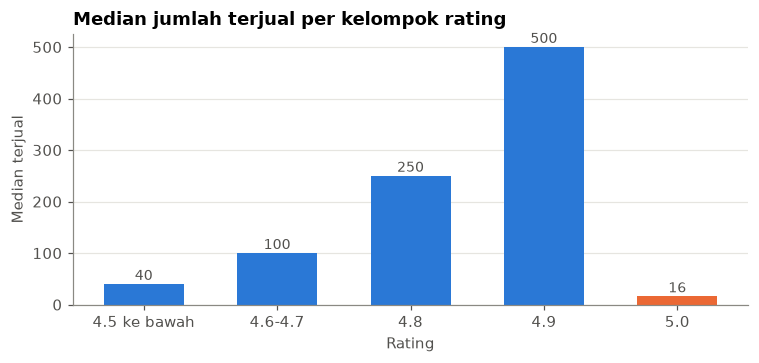

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.4))
warna = [ORANYE if k == "5.0" else BIRU for k in per_rating.index]
ax.bar(per_rating.index.astype(str), per_rating["median_terjual"], color=warna, width=0.6)
for x, v in enumerate(per_rating["median_terjual"]):
    ax.text(x, v + 8, angka(v), ha="center", fontsize=9, color=TEKS)
ax.set_title("Median jumlah terjual per kelompok rating")
ax.set_xlabel("Rating")
ax.set_ylabel("Median terjual")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Temuan:

- Produk dengan rating sempurna 5.0 justru punya median terjual paling rendah (16), sedangkan produk ber-rating 4.9 punya median 500.
- Penyebabnya terlihat dari kolom median ulasan. Produk ber-rating 5.0 umumnya baru punya sedikit ulasan (median 5). Dengan sedikit pembeli, sangat mudah untuk mendapat rating sempurna. Sebaliknya, produk yang sudah dibeli ratusan orang hampir pasti pernah dapat satu atau dua bintang rendah, sehingga rating-nya turun sedikit ke 4.8 atau 4.9.
- Jadi rating 5.0 lebih sering berarti "belum banyak pembeli", bukan "produk terbaik". Kalau rating ingin dipakai untuk menilai kualitas, sebaiknya hanya dibandingkan antarproduk yang jumlah ulasannya sudah cukup banyak, misalnya minimal 50 ulasan.

## 4. Kata kunci di nama produk dan pengaruhnya terhadap harga

Penjual sering menambahkan kata seperti "Premium", "Murah", atau "Original" di nama produk. Pertanyaannya, apakah produk dengan kata-kata itu memang berbeda harganya?

Membandingkan harga secara langsung akan menyesatkan. Misalnya, kata "original" sering dipakai di produk elektronik yang memang mahal, sehingga harga tinggi itu disebabkan kategorinya, bukan kata "original"-nya. Karena itu harga setiap produk dibandingkan dengan median harga kategorinya sendiri:

`indeks harga = harga produk / median harga kategorinya`

Indeks 1,0 berarti harganya sama dengan median kategorinya. Indeks 2,0 berarti dua kali lipat, dan 0,5 berarti setengahnya.

In [16]:
KATA_KUNCI = {
    "premium": r"\bpremium\b",
    "murah": r"\b(?:murah|termurah)\b",
    "original": r"\b(?:original|ori|asli)\b",
    "official": r"\bofficial\b",
    "promo": r"\bpromo\b",
    "import": r"\bimport\b",
    "mewah": r"\b(?:mewah|luxury)\b",
    "terlaris": r"\b(?:terlaris|best seller|bestseller)\b",
    "grosir": r"\bgrosir\b",
}

nama = df["nama_produk"].str.lower()
df["indeks_harga"] = df["harga"] / df.groupby("kategori")["harga"].transform("median")

hasil = []
for kata, pola in KATA_KUNCI.items():
    ada = nama.str.contains(pola, regex=True)
    hasil.append({
        "kata_kunci": kata,
        "jumlah_produk": ada.sum(),
        "persen_produk": ada.mean(),
        "median_harga": df.loc[ada, "harga"].median(),
        "median_indeks_harga": df.loc[ada, "indeks_harga"].median(),
    })

kata_kunci = pd.DataFrame(hasil).sort_values("median_indeks_harga").set_index("kata_kunci")
kata_kunci.style.format({
    "persen_produk": "{:.1%}",
    "median_harga": rupiah,
    "median_indeks_harga": "{:.2f}",
})

,jumlah_produk,persen_produk,median_harga,median_indeks_harga
kata_kunci,,,,
grosir,118,0.4%,Rp26.625,0.31
murah,1642,5.6%,Rp58.167,0.53
terlaris,489,1.7%,Rp82.650,0.81
premium,1366,4.7%,Rp81.340,0.83
import,240,0.8%,Rp90.000,0.86
promo,543,1.9%,Rp98.500,1.10
original,3560,12.2%,Rp149.900,1.35
mewah,216,0.7%,Rp128.000,1.38
official,235,0.8%,Rp183.670,1.48


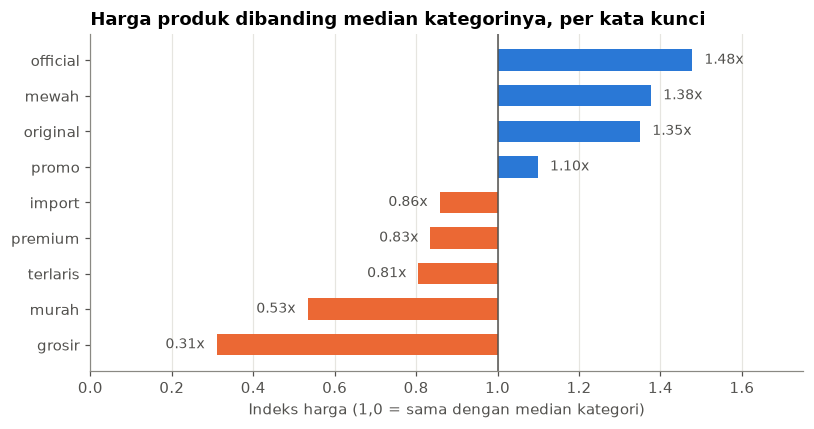

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4))
nilai = kata_kunci["median_indeks_harga"]
warna = [BIRU if v >= 1 else ORANYE for v in nilai]
ax.barh(nilai.index, nilai - 1, left=1, color=warna, height=0.6)
ax.axvline(1, color=TEKS, linewidth=1)
for y, v in enumerate(nilai):
    ax.text(v + (0.03 if v >= 1 else -0.03), y, f"{v:.2f}x", va="center",
            ha="left" if v >= 1 else "right", fontsize=9, color=TEKS)
ax.set_xlim(0, 1.75)
ax.set_title("Harga produk dibanding median kategorinya, per kata kunci")
ax.set_xlabel("Indeks harga (1,0 = sama dengan median kategori)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Temuan:

- "Original" adalah kata kunci yang paling sering dipakai (sekitar 12% produk) dan berkaitan dengan harga yang lebih tinggi, sekitar 1,4 kali median kategorinya. Kata ini umumnya dipakai untuk barang bermerek, yang memang lebih mahal dari barang tanpa merek.
- "Official" punya indeks tertinggi, sekitar 1,5 kali. Produk dari toko resmi merek harganya jauh di atas median kategorinya.
- "Mewah" juga berkaitan dengan harga yang lebih tinggi, sekitar 1,4 kali, jadi kata ini cukup sesuai dengan harganya.
- "Murah" dan "grosir" sesuai dengan artinya. Produk dengan kata "murah" harganya sekitar setengah median kategorinya, dan "grosir" lebih rendah lagi.
- "Premium" tidak menunjukkan harga yang lebih tinggi. Indeksnya justru di bawah 1 (sekitar 0,83). Artinya kata "premium" lebih banyak dipakai sebagai kata pemasaran daripada penanda produk kelas atas. Pola yang sama terlihat pada "terlaris" dan "import", yang keduanya sekitar 0,8.
- "Promo" hanya sedikit di atas 1 (sekitar 1,1), sehingga pengaruhnya terhadap harga kecil.

Hasil ini bisa berguna bagi penjual. Menambahkan kata "premium" tidak otomatis membuat produk terlihat kelas atas di mata pasar, sedangkan status "original" atau "official" berkaitan dengan harga yang lebih tinggi.

## Kesimpulan

1. Harga per kategori: Elektronik dan Perhiasan adalah kategori termahal dengan rentang harga paling lebar. Makanan & Minuman termurah. Perbandingan harga sebaiknya selalu dilakukan di dalam kategori yang sama.
2. Wilayah: penjual dan penjualan sangat terpusat di Jabodetabek. DKI Jakarta menyumbang 46% toko dan 51% total terjual. Banten, terutama Tangerang, punya median terjual per produk tertinggi.
3. Rating, diskon, dan terjual: produk berdiskon cenderung lebih laris, tetapi diskon besar tidak menjamin produk laris, dan hubungan ini belum tentu sebab-akibat. Rating 5.0 lebih sering berarti produk baru punya sedikit pembeli, bukan produk terbaik.
4. Kata kunci: "original", "mewah", dan "official" berkaitan dengan harga yang lebih tinggi, sedangkan "murah" dan "grosir" dengan harga yang lebih rendah. "Premium" justru berkaitan dengan harga di bawah median kategorinya, jadi lebih berfungsi sebagai kata pemasaran.

Keterbatasan analisis:

- `terjual` adalah batas bawah dan berbentuk kelompok angka bulat, bukan angka penjualan pasti.
- Kategori dibuat dari kata kunci, jadi sebagian produk salah kategori atau masuk "Lainnya".
- Sekitar 10% produk tidak punya informasi provinsi dan tidak ikut dalam analisis wilayah.
- Data adalah potret satu waktu, jadi hasilnya menunjukkan hubungan, bukan sebab-akibat.